# Noise Detection with DINOv3: Experiment 1

This notebook loads a SigMF recording, computes a spectrogram, extracts DINOv3 patch features from the spectrogram image, visualizes PCA and t-SNE embeddings, performs kNN-graph clustering with $k=2$ on t-SNE coordinates, and overlays the two clusters on the original spectrogram.

In [ ]:
import json
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy import signal
from scipy.sparse.csgraph import connected_components

import torch
import torchvision.transforms as T

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.neighbors import kneighbors_graph

# ===== Config =====
#SIGMF_META_PATH = '/home/sat3737/holoscan_demo_workspace/test_data/DJI_inspire_2_5G.sigmf-meta'
SIGMF_META_PATH= '/home/sat3737/holoscan_demo_workspace/test_data/SIGINT_DAY_DEMO_all_16_Emitter_noNoise.sigmf-meta'
DINOV3_LOCATION = '/home/sat3737/holoscan_demo_workspace/dinov3'
MODEL_NAME = 'dinov3_vitb16'
WEIGHTS_PATH = '/home/sat3737/holoscan_demo_workspace/dinov3_weights/dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth'

FFT_SIZE = 1024
NOVERLAP = 512
SAMPLE_OFFSET_S = 0.10
DEFAULT_CHUNK_SECONDS = 1.0
USRP_SPECTROGRAM_DIR = '/tmp/usrp_spectrograms'
USE_USRP_CHUNK_DURATION = True
USE_USRP_SHAPE_MATCH = True
TSNE_PERPLEXITY = 30
TSNE_RANDOM_STATE = 42

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
np.random.seed(42)
print(f'Device: {DEVICE}')

Device: cpu


In [9]:
weights_file = Path(WEIGHTS_PATH)
if not weights_file.exists():
    raise FileNotFoundError(f'DINO weights not found: {weights_file}')

use_local_repo = Path(DINOV3_LOCATION).exists() and (Path(DINOV3_LOCATION) / 'hubconf.py').exists()

if use_local_repo:
    model = torch.hub.load(
        repo_or_dir=DINOV3_LOCATION,
        model=MODEL_NAME,
        source='local',
        weights=str(weights_file),
    )
else:
    model = torch.hub.load(
        repo_or_dir='facebookresearch/dinov3',
        model=MODEL_NAME,
        source='github',
        weights=str(weights_file),
    )

model.to(DEVICE).eval()
DINO_PATCH_SIZE = int(getattr(model, 'patch_size', 16))
print(f"Loaded {MODEL_NAME} (patch_size={DINO_PATCH_SIZE}) from {'local' if use_local_repo else 'github'}")

Using cache found in /home/sat3737/.cache/torch/hub/facebookresearch_dinov3_main


Loaded dinov3_vitb16 (patch_size=16) from github


In [10]:
def read_sigmf_meta(meta_path):
    meta_path = Path(meta_path)
    with meta_path.open('r') as f:
        meta = json.load(f)
    global_info = meta.get('global', {})
    captures = meta.get('captures', [])
    annotations = meta.get('annotations', [])
    return meta, global_info, captures, annotations


def _sigmf_dtype_info(datatype):
    if not datatype:
        raise ValueError('SigMF datatype is missing')

    if datatype.endswith('_le'):
        endian = '<'
        base = datatype[:-3]
    elif datatype.endswith('_be'):
        endian = '>'
        base = datatype[:-3]
    else:
        endian = '<'
        base = datatype

    is_complex = base.startswith('c')
    scalar_spec = base[1:] if is_complex else base
    if len(scalar_spec) < 2:
        raise ValueError(f'Unsupported SigMF datatype: {datatype}')

    scalar_kind = scalar_spec[0]
    bits = int(scalar_spec[1:])
    bytes_per = bits // 8
    kind_map = {'i': 'i', 'u': 'u', 'f': 'f'}
    if scalar_kind not in kind_map:
        raise ValueError(f'Unsupported SigMF datatype: {datatype}')

    dtype = np.dtype(f'{endian}{kind_map[scalar_kind]}{bytes_per}')
    return dtype, is_complex


def _load_sigmf_iq(data_path, dtype, is_complex, start_sample, count, num_channels=1, channel=0):
    data_path = Path(data_path)
    bytes_per_scalar = dtype.itemsize
    scalars_per_sample = (2 if is_complex else 1) * num_channels

    file_size = data_path.stat().st_size
    total_samples = file_size // (bytes_per_scalar * scalars_per_sample)
    if start_sample < 0 or start_sample >= total_samples:
        raise ValueError('start_sample is outside file bounds')

    if count is None:
        count = total_samples - start_sample
    count = min(count, total_samples - start_sample)

    scalar_start = start_sample * scalars_per_sample
    scalar_count = count * scalars_per_sample
    data = np.memmap(
        data_path,
        dtype=dtype,
        mode='r',
        offset=scalar_start * bytes_per_scalar,
        shape=(scalar_count,),
    )

    if is_complex:
        data = data.reshape(-1, num_channels, 2)
        i = data[:, channel, 0].astype(np.float32)
        q = data[:, channel, 1].astype(np.float32)
        samples = i + 1j * q
    else:
        data = data.reshape(-1, num_channels)
        samples = data[:, channel].astype(np.float32)

    return np.asarray(samples)


def load_sigmf_samples(meta_path, start_s=0.0, duration_s=1.0, capture_index=0, channel=0):
    _, global_info, captures, _ = read_sigmf_meta(meta_path)

    sample_rate = global_info.get('core:sample_rate')
    datatype = global_info.get('core:datatype')
    num_channels = int(global_info.get('core:num_channels', 1))
    capture = captures[capture_index] if captures else {}
    capture_start = int(capture.get('core:sample_start', 0))
    center_frequency = capture.get('core:frequency', None)

    if sample_rate is None:
        raise ValueError('SigMF metadata missing core:sample_rate')

    dtype, is_complex = _sigmf_dtype_info(datatype)
    start_sample = capture_start + int(start_s * sample_rate)
    count = int(duration_s * sample_rate) if duration_s is not None else None

    data_path = str(meta_path).replace('.sigmf-meta', '.sigmf-data')
    samples = _load_sigmf_iq(
        data_path=data_path,
        dtype=dtype,
        is_complex=is_complex,
        start_sample=start_sample,
        count=count,
        num_channels=num_channels,
        channel=channel,
    )

    params = {
        'sample_rate': float(sample_rate),
        'datatype': datatype,
        'num_channels': num_channels,
        'center_frequency': center_frequency,
    }
    return samples, params


def generate_spectrogram(iq_data, fs, nperseg=1024, noverlap=512, center_frequency=None):
    f, t, sxx = signal.spectrogram(
        iq_data,
        fs=fs,
        nperseg=nperseg,
        noverlap=noverlap,
        return_onesided=False,
    )
    sxx = np.fft.fftshift(sxx, axes=0)
    f = np.fft.fftshift(f) - fs / 2
    if center_frequency is not None:
        f = f + center_frequency
    sxx_db = 10.0 * np.log10(sxx + 1e-10)
    return f, t, sxx_db


def spectrogram_to_rgb(sxx_db, vmin=None, vmax=None):
    from matplotlib import colormaps

    if vmin is None:
        vmin = float(np.percentile(sxx_db, 1))
    if vmax is None:
        vmax = float(np.percentile(sxx_db, 99))

    denom = (vmax - vmin) if (vmax - vmin) > 0 else 1.0
    x = np.clip((sxx_db - vmin) / denom, 0.0, 1.0)
    rgb = (colormaps['viridis'](x)[..., :3] * 255).astype(np.uint8)
    return Image.fromarray(rgb), vmin, vmax


def infer_usrp_chunk_duration_seconds(spectrogram_dir):
    spectrogram_dir = Path(spectrogram_dir)
    if not spectrogram_dir.exists():
        return None, None

    files = sorted(spectrogram_dir.glob('spectrogram_ch*_*.pgm'))
    if len(files) < 2:
        return None, None

    ts = []
    shape = None
    for p in files:
        m = re.search(r'_(\d+)_(\d+)x(\d+)\.pgm$', p.name)
        if m is None:
            continue
        ts.append(int(m.group(1)))
        if shape is None:
            shape = (int(m.group(2)), int(m.group(3)))

    if len(ts) < 2:
        return None, shape

    ts = np.array(sorted(ts), dtype=np.int64)
    deltas_ms = np.diff(ts)
    chunk_s = float(np.median(deltas_ms) / 1000.0)
    return chunk_s, shape


def chunk_seconds_for_target_time_bins(sample_rate, target_time_bins, nperseg, noverlap):
    if target_time_bins is None or target_time_bins < 2:
        return None
    hop = nperseg - noverlap
    if hop <= 0:
        raise ValueError('nperseg must be greater than noverlap')
    required_samples = nperseg + (target_time_bins - 1) * hop
    return float(required_samples / sample_rate)

SigMF: /home/sat3737/holoscan_demo_workspace/test_data/DJI_inspire_2_5G.sigmf-meta
Sample rate: 200000000.00 Hz
USRP reference shape (rows, cols): (250, 512)
USRP inferred chunk duration: 2.022 s
Shape-matched chunk duration for 512 time bins: 0.001313 s
Using chunk duration: 0.001 s
Spectrogram shape: (1024, 512)


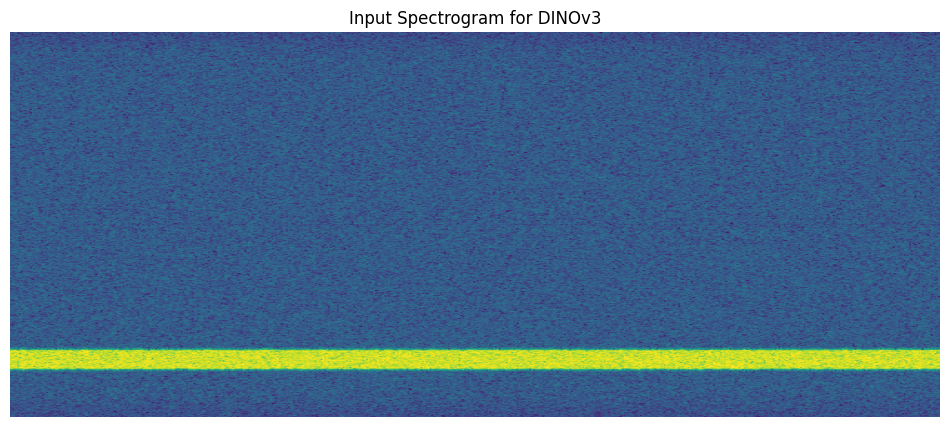

In [11]:
sigmf_path = Path(SIGMF_META_PATH)
if not sigmf_path.exists():
    candidates = sorted(Path('/home/sat3737/holoscan_demo_workspace').rglob('*.sigmf-meta'))
    if not candidates:
        raise FileNotFoundError('No .sigmf-meta files found in workspace')
    sigmf_path = candidates[0]
    print(f'Using first discovered SigMF file: {sigmf_path}')

usrp_chunk_s, usrp_shape = infer_usrp_chunk_duration_seconds(USRP_SPECTROGRAM_DIR)
chunk_seconds = DEFAULT_CHUNK_SECONDS
target_time_bins = None
shape_matched_chunk_s = None
if usrp_shape is not None:
    target_time_bins = int(max(usrp_shape))

if USE_USRP_SHAPE_MATCH and (target_time_bins is not None):
    # Match time-axis bin count to USRP image width while keeping FFT_SIZE fixed.
    _, probe_params = load_sigmf_samples(
        sigmf_path,
        start_s=SAMPLE_OFFSET_S,
        duration_s=0.01,
        capture_index=0,
        channel=0,
    )
    shape_matched_chunk_s = chunk_seconds_for_target_time_bins(
        sample_rate=probe_params['sample_rate'],
        target_time_bins=target_time_bins,
        nperseg=FFT_SIZE,
        noverlap=NOVERLAP,
    )
    if shape_matched_chunk_s is not None:
        chunk_seconds = shape_matched_chunk_s
elif USE_USRP_CHUNK_DURATION and (usrp_chunk_s is not None):
    chunk_seconds = usrp_chunk_s

iq, params = load_sigmf_samples(
    sigmf_path,
    start_s=SAMPLE_OFFSET_S,
    duration_s=chunk_seconds,
    capture_index=0,
    channel=0,
)

fs = params['sample_rate']
center_frequency = params['center_frequency']
f, t, sxx_db = generate_spectrogram(iq, fs=fs, nperseg=FFT_SIZE, noverlap=NOVERLAP, center_frequency=center_frequency)
spec_img, vmin, vmax = spectrogram_to_rgb(sxx_db)

print(f'SigMF: {sigmf_path}')
print(f'Sample rate: {fs:.2f} Hz')
if usrp_shape is not None:
    print(f'USRP reference shape (rows, cols): {usrp_shape}')
if usrp_chunk_s is not None:
    print(f'USRP inferred chunk duration: {usrp_chunk_s:.3f} s')
if shape_matched_chunk_s is not None:
    print(f'Shape-matched chunk duration for {target_time_bins} time bins: {shape_matched_chunk_s:.6f} s')
print(f'Using chunk duration: {chunk_seconds:.3f} s')
print(f'Spectrogram shape: {sxx_db.shape}')

plt.figure(figsize=(12, 5))
plt.imshow(spec_img, aspect='auto')
plt.title('Input Spectrogram for DINOv3')
plt.axis('off')
plt.show()

In [12]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

w = (spec_img.size[0] // DINO_PATCH_SIZE) * DINO_PATCH_SIZE
h = (spec_img.size[1] // DINO_PATCH_SIZE) * DINO_PATCH_SIZE
resized_img = spec_img.crop((0, 0, w, h))

transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

img_tensor = transform(resized_img).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    feat = model.get_intermediate_layers(img_tensor, n=1, reshape=True, norm=True)[0]

features = feat.squeeze().view(feat.shape[1], -1).permute(1, 0).cpu().numpy()
grid_h = resized_img.size[1] // DINO_PATCH_SIZE
grid_w = resized_img.size[0] // DINO_PATCH_SIZE

print(f'Resized image: {resized_img.size}')
print(f'Patch grid: {grid_h} x {grid_w}')
print(f'Feature matrix: {features.shape}')

Resized image: (512, 1024)
Patch grid: 64 x 32
Feature matrix: (2048, 768)


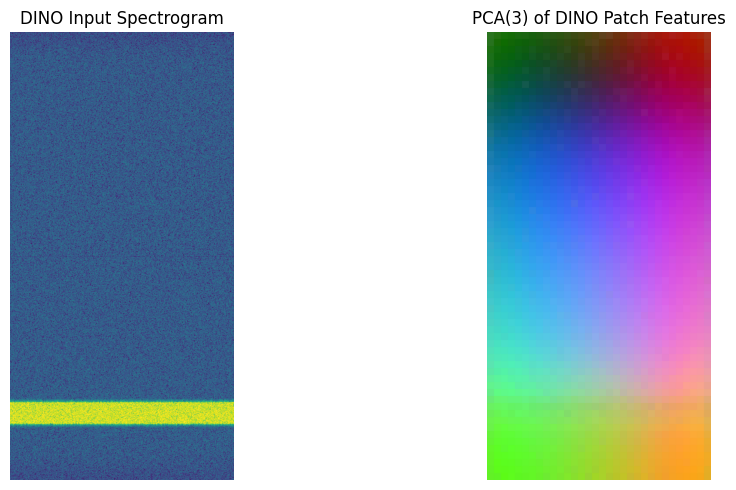

Explained variance ratio: [0.2531347  0.2419566  0.14079385]


In [13]:
pca = PCA(n_components=3, random_state=42)
pca_features = pca.fit_transform(features)

pmin = pca_features.min(axis=0, keepdims=True)
pmax = pca_features.max(axis=0, keepdims=True)
pca_scaled = (pca_features - pmin) / np.maximum(pmax - pmin, 1e-8)
pca_img = (255 * pca_scaled).astype(np.uint8).reshape(grid_h, grid_w, 3)
pca_up = Image.fromarray(pca_img).resize(resized_img.size, Image.NEAREST)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(resized_img)
plt.title('DINO Input Spectrogram')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(pca_up)
plt.title('PCA(3) of DINO Patch Features')
plt.axis('off')

plt.tight_layout()
plt.show()

print('Explained variance ratio:', pca.explained_variance_ratio_)

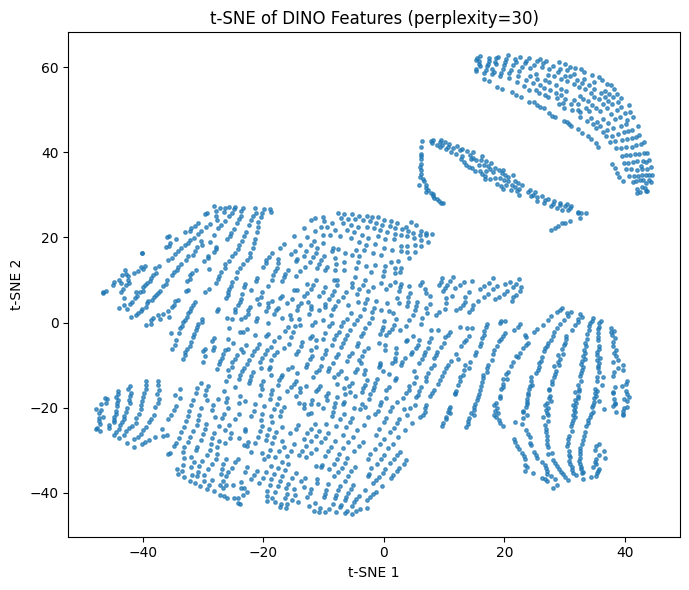

In [14]:
# t-SNE on DINO patch embeddings
perplexity = min(TSNE_PERPLEXITY, max(5, (features.shape[0] - 1) // 3))
tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    learning_rate='auto',
    init='pca',
    random_state=TSNE_RANDOM_STATE,
)
emb_tsne = tsne.fit_transform(features)

plt.figure(figsize=(7, 6))
plt.scatter(emb_tsne[:, 0], emb_tsne[:, 1], s=6, alpha=0.7)
plt.title(f't-SNE of DINO Features (perplexity={perplexity})')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.show()

Cluster counts: [ 383 1665]


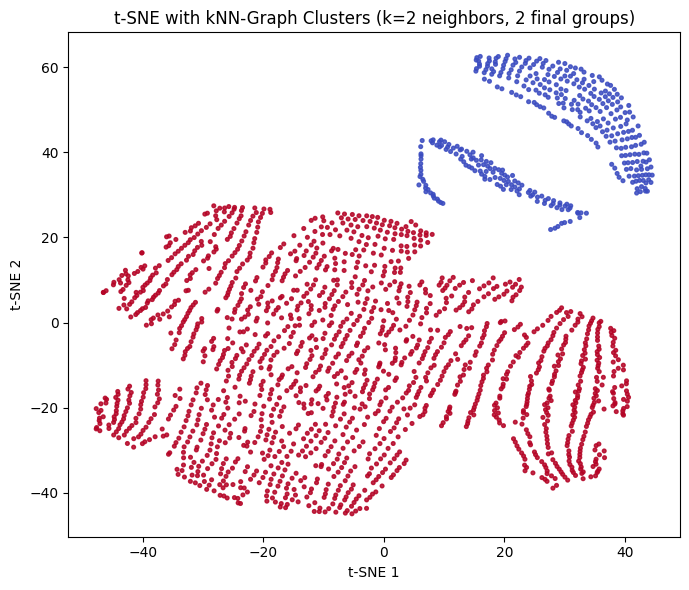

In [15]:
# kNN-graph clustering on t-SNE coordinates with k=2
def knn_graph_two_clusters(xy, k_neighbors=2, random_state=42):
    graph = kneighbors_graph(xy, n_neighbors=k_neighbors, mode='connectivity', include_self=False)
    graph = graph.maximum(graph.T)

    n_comp, comp_labels = connected_components(graph, directed=False)

    if n_comp == 1:
        # Fallback to force 2 clusters when graph is fully connected
        km = KMeans(n_clusters=2, random_state=random_state, n_init=20)
        return km.fit_predict(xy)

    counts = np.bincount(comp_labels)
    top2 = np.argsort(counts)[-2:]

    out = np.full(comp_labels.shape, -1, dtype=np.int32)
    out[comp_labels == top2[0]] = 0
    out[comp_labels == top2[1]] = 1

    missing = np.where(out < 0)[0]
    if len(missing) > 0:
        c0 = xy[out == 0].mean(axis=0)
        c1 = xy[out == 1].mean(axis=0)
        d0 = np.sum((xy[missing] - c0) ** 2, axis=1)
        d1 = np.sum((xy[missing] - c1) ** 2, axis=1)
        out[missing] = (d1 < d0).astype(np.int32)

    return out

cluster_labels = knn_graph_two_clusters(emb_tsne, k_neighbors=2, random_state=42)
cluster_map = cluster_labels.reshape(grid_h, grid_w)

print('Cluster counts:', np.bincount(cluster_labels))

plt.figure(figsize=(7, 6))
plt.scatter(emb_tsne[:, 0], emb_tsne[:, 1], c=cluster_labels, cmap='coolwarm', s=7, alpha=0.85)
plt.title('t-SNE with kNN-Graph Clusters (k=2 neighbors, 2 final groups)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.show()

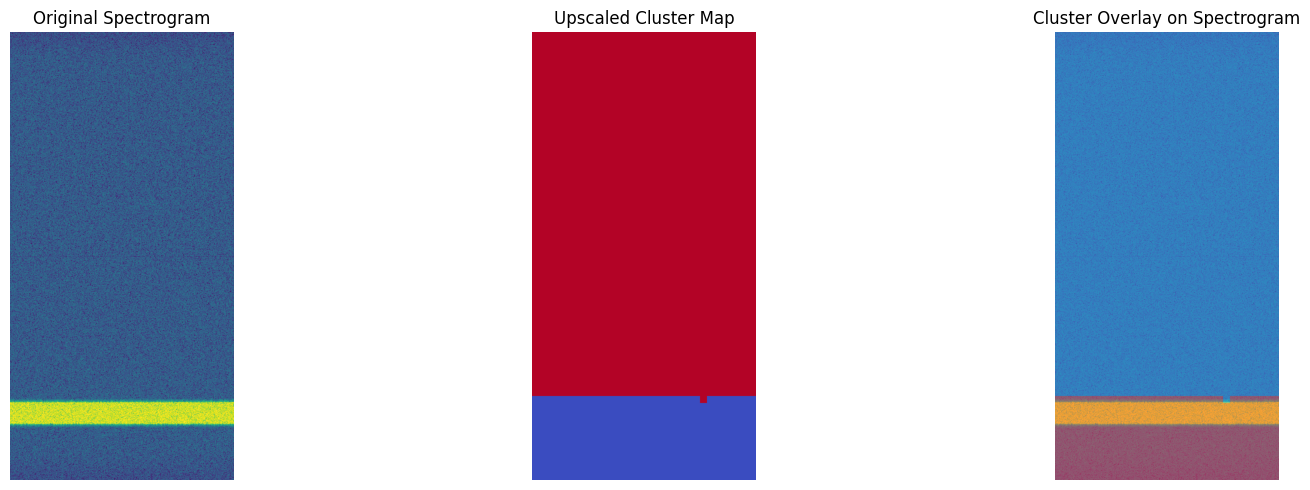

In [16]:
# Overlay cluster map on top of original spectrogram
cluster_img = Image.fromarray((cluster_map * 255).astype(np.uint8), mode='L').resize(resized_img.size, Image.NEAREST)
cluster_mask = np.array(cluster_img)
base = np.array(resized_img).astype(np.float32)

overlay = base.copy()
alpha = 0.45

cluster0 = cluster_mask < 128
cluster1 = ~cluster0

color0 = np.array([255, 80, 80], dtype=np.float32)
color1 = np.array([50, 170, 255], dtype=np.float32)

overlay[cluster0] = (1 - alpha) * overlay[cluster0] + alpha * color0
overlay[cluster1] = (1 - alpha) * overlay[cluster1] + alpha * color1
overlay = overlay.astype(np.uint8)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].imshow(resized_img)
ax[0].set_title('Original Spectrogram')
ax[0].axis('off')

ax[1].imshow(cluster_mask, cmap='coolwarm')
ax[1].set_title('Upscaled Cluster Map')
ax[1].axis('off')

ax[2].imshow(overlay)
ax[2].set_title('Cluster Overlay on Spectrogram')
ax[2].axis('off')

plt.tight_layout()
plt.show()

## Comparative Experiments: Ideas 1, 3, and 4

This section compares:
1. **Idea 1**: Grayscale + fixed dB scaling before DINO.
2. **Idea 3**: Cluster in embedding/PCA space (use t-SNE only for visualization).
3. **Idea 4**: Apply a local smoothness prior to the clustered patch map.

The cells below compute each variant, then compare overlays and simple quality metrics.

In [17]:
import pandas as pd
from scipy import ndimage

# ---- Helpers ----
def _prep_dino_image(img_rgb):
    w = (img_rgb.size[0] // DINO_PATCH_SIZE) * DINO_PATCH_SIZE
    h = (img_rgb.size[1] // DINO_PATCH_SIZE) * DINO_PATCH_SIZE
    return img_rgb.crop((0, 0, w, h))


def _extract_dino_features_from_rgb(img_rgb):
    img_rgb = _prep_dino_image(img_rgb)
    transform_local = T.Compose([
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    x = transform_local(img_rgb).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        feat_local = model.get_intermediate_layers(x, n=1, reshape=True, norm=True)[0]
    feat_local = feat_local.squeeze().view(feat_local.shape[1], -1).permute(1, 0).cpu().numpy()
    gh = img_rgb.size[1] // DINO_PATCH_SIZE
    gw = img_rgb.size[0] // DINO_PATCH_SIZE
    return feat_local, gh, gw, img_rgb


def _db_to_fixed_grayscale_rgb(sxx_db_local, db_min=-110.0, db_max=-40.0):
    x = np.clip((sxx_db_local - db_min) / max(db_max - db_min, 1e-8), 0.0, 1.0)
    gray = (255.0 * x).astype(np.uint8)
    rgb = np.stack([gray, gray, gray], axis=-1)
    return Image.fromarray(rgb)


def _labels_from_tsne_knn(x_feat, k_neighbors=2, seed=42):
    perplexity_local = min(TSNE_PERPLEXITY, max(5, (x_feat.shape[0] - 1) // 3))
    tsne_local = TSNE(
        n_components=2,
        perplexity=perplexity_local,
        learning_rate='auto',
        init='pca',
        random_state=seed,
    )
    emb_local = tsne_local.fit_transform(x_feat)
    labels_local = knn_graph_two_clusters(emb_local, k_neighbors=k_neighbors, random_state=seed)
    return labels_local, emb_local, perplexity_local


def _labels_from_embedding_pca_kmeans(x_feat, n_pca=8, seed=42):
    n_comp = min(n_pca, x_feat.shape[1], x_feat.shape[0] - 1)
    pca_local = PCA(n_components=n_comp, random_state=seed)
    x_pca = pca_local.fit_transform(x_feat)
    km = KMeans(n_clusters=2, random_state=seed, n_init=20)
    labels_local = km.fit_predict(x_pca)
    return labels_local, x_pca, pca_local.explained_variance_ratio_


def _smooth_binary_label_map(label_map, iters=2, min_component_size=6):
    out = label_map.copy().astype(np.uint8)

    for _ in range(iters):
        avg = ndimage.uniform_filter(out.astype(np.float32), size=3, mode='nearest')
        out = (avg >= 0.5).astype(np.uint8)

    # Remove tiny islands for each class and fill from neighborhood majority.
    for cls in [0, 1]:
        mask = (out == cls)
        comp, n_comp = ndimage.label(mask)
        if n_comp == 0:
            continue
        sizes = ndimage.sum(mask, comp, index=np.arange(1, n_comp + 1))
        small_ids = np.where(sizes < min_component_size)[0] + 1
        if len(small_ids) == 0:
            continue
        small_mask = np.isin(comp, small_ids)
        neigh = ndimage.uniform_filter(out.astype(np.float32), size=3, mode='nearest')
        out[small_mask] = (neigh[small_mask] >= 0.5).astype(np.uint8)

    return out


def _overlay_from_label_map(base_img_rgb, label_map_patch, alpha=0.45):
    up = Image.fromarray((label_map_patch * 255).astype(np.uint8), mode='L').resize(base_img_rgb.size, Image.NEAREST)
    mask = np.array(up) >= 128
    base = np.array(base_img_rgb).astype(np.float32)
    over = base.copy()
    c0 = np.array([255, 80, 80], dtype=np.float32)
    c1 = np.array([50, 170, 255], dtype=np.float32)
    over[~mask] = (1 - alpha) * over[~mask] + alpha * c0
    over[mask] = (1 - alpha) * over[mask] + alpha * c1
    return over.astype(np.uint8)


def _spatial_metrics(label_map_patch):
    v_dis = np.mean(label_map_patch[1:, :] != label_map_patch[:-1, :])
    h_dis = np.mean(label_map_patch[:, 1:] != label_map_patch[:, :-1])
    edge_disagreement = 0.5 * (v_dis + h_dis)
    smoothness = 1.0 - edge_disagreement

    comp0, n0 = ndimage.label(label_map_patch == 0)
    comp1, n1 = ndimage.label(label_map_patch == 1)
    frac1 = float(np.mean(label_map_patch == 1))
    frac0 = 1.0 - frac1
    balance = min(frac0, frac1) / max(frac0, frac1, 1e-8)

    return {
        'smoothness': smoothness,
        'edge_disagreement': edge_disagreement,
        'num_components_total': int(n0 + n1),
        'frac_class1': frac1,
        'balance': balance,
    }


# ---- Baseline from existing features (already computed earlier in notebook) ----
base_img = resized_img
base_labels = cluster_labels.reshape(grid_h, grid_w)

# ---- Idea 1: fixed grayscale preprocessing before DINO ----
gray_rgb = _db_to_fixed_grayscale_rgb(sxx_db, db_min=-110.0, db_max=-40.0)
feat_i1, gh1, gw1, img_i1 = _extract_dino_features_from_rgb(gray_rgb)
labels_i1, emb_i1_tsne, perplex_i1 = _labels_from_tsne_knn(feat_i1, k_neighbors=2, seed=42)
map_i1 = labels_i1.reshape(gh1, gw1)

# ---- Idea 3: cluster in embedding/PCA space (not in t-SNE space) ----
labels_i3, x_i3_pca, var_i3 = _labels_from_embedding_pca_kmeans(feat_i1, n_pca=8, seed=42)
map_i3 = labels_i3.reshape(gh1, gw1)

# t-SNE is visualization only here
perplex_i3 = min(TSNE_PERPLEXITY, max(5, (feat_i1.shape[0] - 1) // 3))
tsne_i3 = TSNE(
    n_components=2,
    perplexity=perplex_i3,
    learning_rate='auto',
    init='pca',
    random_state=42,
)
emb_i3_tsne = tsne_i3.fit_transform(feat_i1)

# ---- Idea 4: local smoothness prior over Idea 3 map ----
map_i4 = _smooth_binary_label_map(map_i3, iters=2, min_component_size=6)

# ---- Collect overlays and metrics ----
overlays = {
    'baseline_current': _overlay_from_label_map(base_img, base_labels),
    'idea1_gray_fixeddb': _overlay_from_label_map(img_i1, map_i1),
    'idea3_pca_cluster': _overlay_from_label_map(img_i1, map_i3),
    'idea4_smoothed': _overlay_from_label_map(img_i1, map_i4),
}

metric_rows = []
for name, m in {
    'baseline_current': _spatial_metrics(base_labels),
    'idea1_gray_fixeddb': _spatial_metrics(map_i1),
    'idea3_pca_cluster': _spatial_metrics(map_i3),
    'idea4_smoothed': _spatial_metrics(map_i4),
}.items():
    m['method'] = name
    metric_rows.append(m)

comparison_df = pd.DataFrame(metric_rows).set_index('method').sort_values('smoothness', ascending=False)
print('Comparison metrics (higher smoothness, lower edge_disagreement, fewer components are usually better):')
display(comparison_df)

print(f'Idea 1 t-SNE perplexity: {perplex_i1}')
print(f'Idea 3 PCA variance retained (8 comps max): {float(np.sum(var_i3)):.3f}')

Comparison metrics (higher smoothness, lower edge_disagreement, fewer components are usually better):


,smoothness,edge_disagreement,num_components_total,frac_class1,balance
method,,,,,
baseline_current,0.991559,0.008441,2,0.812988,0.230030
idea4_smoothed,0.989795,0.010205,2,0.497559,0.990282
idea3_pca_cluster,0.989039,0.010961,2,0.497559,0.990282
idea1_gray_fixeddb,0.978223,0.021777,3,0.849609,0.177011


Idea 1 t-SNE perplexity: 30
Idea 3 PCA variance retained (8 comps max): 0.888


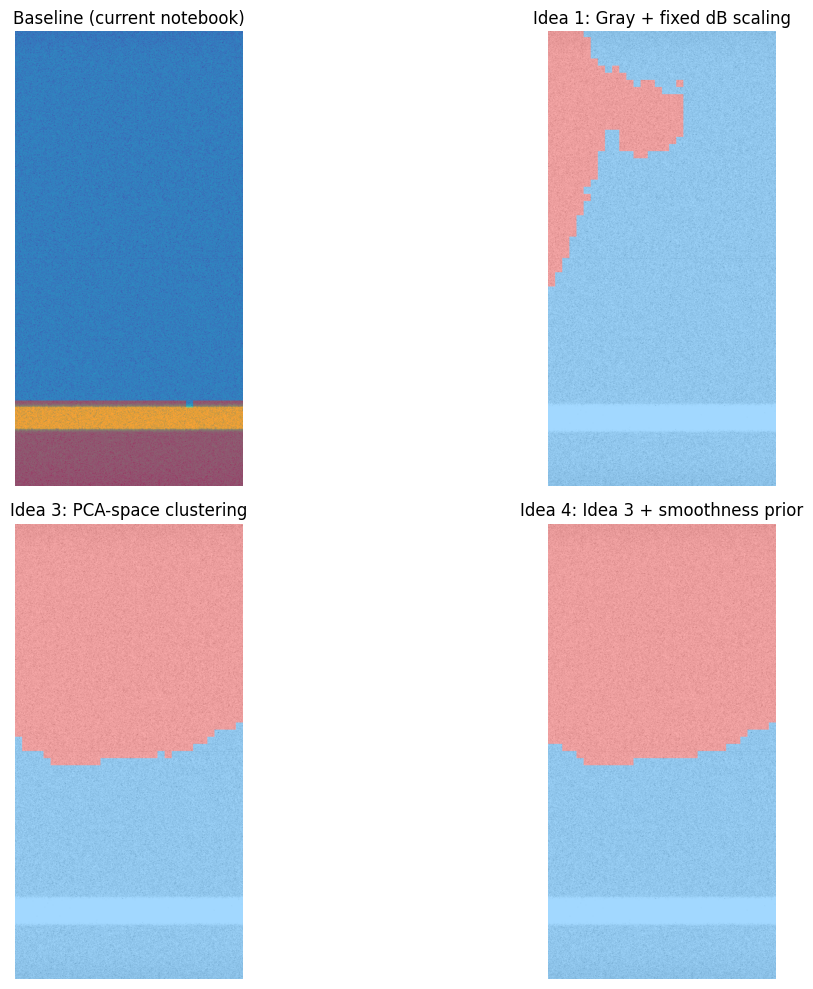

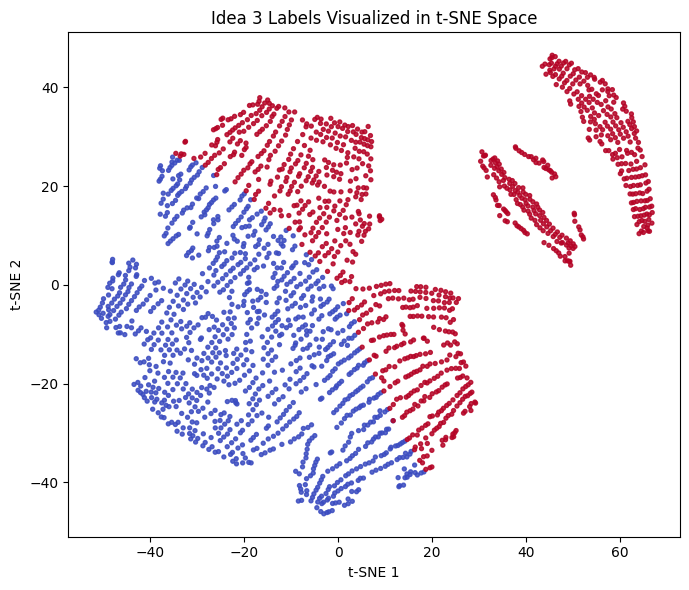

In [18]:
# Visual comparison of the four outputs
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

ax[0, 0].imshow(overlays['baseline_current'])
ax[0, 0].set_title('Baseline (current notebook)')
ax[0, 0].axis('off')

ax[0, 1].imshow(overlays['idea1_gray_fixeddb'])
ax[0, 1].set_title('Idea 1: Gray + fixed dB scaling')
ax[0, 1].axis('off')

ax[1, 0].imshow(overlays['idea3_pca_cluster'])
ax[1, 0].set_title('Idea 3: PCA-space clustering')
ax[1, 0].axis('off')

ax[1, 1].imshow(overlays['idea4_smoothed'])
ax[1, 1].set_title('Idea 4: Idea 3 + smoothness prior')
ax[1, 1].axis('off')

plt.tight_layout()
plt.show()

# Show Idea 3 labels in t-SNE space (visualization-only embedding)
plt.figure(figsize=(7, 6))
plt.scatter(emb_i3_tsne[:, 0], emb_i3_tsne[:, 1], c=labels_i3, cmap='coolwarm', s=8, alpha=0.85)
plt.title('Idea 3 Labels Visualized in t-SNE Space')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.show()

## Literature-Aligned Implementations (Corrected)

This section implements the methods you intended:
1. **Robust PCA / low-rank + sparse residual**
2. **Unsupervised anomaly segmentation (feature-space density)**
3. **Texture segmentation via non-local self-similarity**
4. **CFAR-style local statistical detection**

All methods are converted to patch-level masks and overlaid on the same spectrogram for direct comparison.

In [19]:
from sklearn.neighbors import NearestNeighbors
from scipy import ndimage

# ---- Utility helpers ----
def _to_patch_map_from_pixel_mask(mask_px, patch_h, patch_w, threshold=0.25):
    h_px, w_px = mask_px.shape
    bh = h_px // patch_h
    bw = w_px // patch_w
    m = mask_px[: patch_h * bh, : patch_w * bw]
    m = m.reshape(patch_h, bh, patch_w, bw).mean(axis=(1, 3))
    return (m >= threshold).astype(np.uint8)


def _overlay_patch_mask(img_rgb, patch_mask, alpha=0.45):
    up = Image.fromarray((patch_mask * 255).astype(np.uint8), mode='L').resize(img_rgb.size, Image.NEAREST)
    mask = np.array(up) >= 128
    base = np.array(img_rgb).astype(np.float32)
    out = base.copy()
    c0 = np.array([255, 90, 90], dtype=np.float32)
    c1 = np.array([60, 175, 255], dtype=np.float32)
    out[~mask] = (1 - alpha) * out[~mask] + alpha * c0
    out[mask] = (1 - alpha) * out[mask] + alpha * c1
    return out.astype(np.uint8)


def _smoothness_metrics(mask_patch):
    v_dis = np.mean(mask_patch[1:, :] != mask_patch[:-1, :])
    h_dis = np.mean(mask_patch[:, 1:] != mask_patch[:, :-1])
    edge_dis = 0.5 * (v_dis + h_dis)
    comp0, n0 = ndimage.label(mask_patch == 0)
    comp1, n1 = ndimage.label(mask_patch == 1)
    return {
        'smoothness': 1.0 - edge_dis,
        'edge_disagreement': edge_dis,
        'num_components': int(n0 + n1),
        'foreground_fraction': float(mask_patch.mean()),
    }


def robust_pca_like_mask(sxx_db_local, rank=8, q=0.95):
    # Low-rank approximation via truncated SVD, sparse part as residual outliers.
    X = sxx_db_local.astype(np.float32)
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    r = min(rank, len(S))
    L = (U[:, :r] * S[:r]) @ Vt[:r, :]
    R = np.abs(X - L)
    thr = np.quantile(R, q)
    return (R >= thr)


def feature_density_anomaly_mask(features_local, patch_h, patch_w, pca_dim=12, k=8, q=0.90):
    d = min(pca_dim, features_local.shape[1], features_local.shape[0] - 1)
    X = PCA(n_components=d, random_state=42).fit_transform(features_local)
    knn = NearestNeighbors(n_neighbors=min(k + 1, X.shape[0]), metric='euclidean')
    knn.fit(X)
    dist, _ = knn.kneighbors(X)
    score = dist[:, 1:].mean(axis=1)
    thr = np.quantile(score, q)
    mask = (score >= thr).astype(np.uint8)
    return mask.reshape(patch_h, patch_w), score.reshape(patch_h, patch_w)


def nonlocal_texture_recurrence_mask(img_rgb, patch_h, patch_w, patch_size, k=6, q=0.90):
    gray = np.array(img_rgb.convert('L')).astype(np.float32) / 255.0
    H = patch_h * patch_size
    W = patch_w * patch_size
    gray = gray[:H, :W]
    patches = gray.reshape(patch_h, patch_size, patch_w, patch_size).transpose(0, 2, 1, 3).reshape(-1, patch_size * patch_size)

    patches = patches - patches.mean(axis=1, keepdims=True)
    patches = patches / np.maximum(patches.std(axis=1, keepdims=True), 1e-6)

    # Recurrence score: larger distance to nearest recurring patches => more anomalous.
    nn = NearestNeighbors(n_neighbors=min(k + 1, patches.shape[0]), metric='cosine')
    nn.fit(patches)
    dist, _ = nn.kneighbors(patches)
    rec_score = dist[:, 1:].mean(axis=1)
    thr = np.quantile(rec_score, q)
    mask = (rec_score >= thr).astype(np.uint8)
    return mask.reshape(patch_h, patch_w), rec_score.reshape(patch_h, patch_w)


def cfar_like_mask(sxx_db_local, guard=2, train=8, alpha=3.0):
    # CA-CFAR-like detector in linear power domain.
    P = np.power(10.0, sxx_db_local / 10.0).astype(np.float32)

    win = 2 * (guard + train) + 1
    guard_win = 2 * guard + 1

    kernel_train = np.ones((win, win), dtype=np.float32)
    g0 = train
    g1 = train + guard_win
    kernel_train[g0:g1, g0:g1] = 0.0

    train_count = kernel_train.sum()
    sum_train = ndimage.convolve(P, kernel_train, mode='reflect')
    mu = sum_train / max(train_count, 1.0)

    det = P > (alpha * mu)
    return det


# Shapes for patch-level comparison.
patch_h = resized_img.size[1] // DINO_PATCH_SIZE
patch_w = resized_img.size[0] // DINO_PATCH_SIZE

# 1) Robust PCA style
mask_rpca_px = robust_pca_like_mask(sxx_db, rank=8, q=0.95)
mask_rpca = _to_patch_map_from_pixel_mask(mask_rpca_px, patch_h, patch_w, threshold=0.25)

# 2) Unsupervised anomaly segmentation in feature space
mask_anom, score_anom = feature_density_anomaly_mask(features, patch_h, patch_w, pca_dim=12, k=8, q=0.90)

# 3) Texture non-local self-similarity
mask_tex, score_tex = nonlocal_texture_recurrence_mask(resized_img, patch_h, patch_w, DINO_PATCH_SIZE, k=6, q=0.90)

# 4) CFAR-like local detection
mask_cfar_px = cfar_like_mask(sxx_db, guard=2, train=8, alpha=3.0)
mask_cfar = _to_patch_map_from_pixel_mask(mask_cfar_px, patch_h, patch_w, threshold=0.25)

literature_masks = {
    'robust_pca': mask_rpca,
    'anomaly_density': mask_anom,
    'texture_nonlocal': mask_tex,
    'cfar_like': mask_cfar,
}

literature_overlays = {k: _overlay_patch_mask(resized_img, v) for k, v in literature_masks.items()}

print('Literature-aligned methods computed.')

Literature-aligned methods computed.


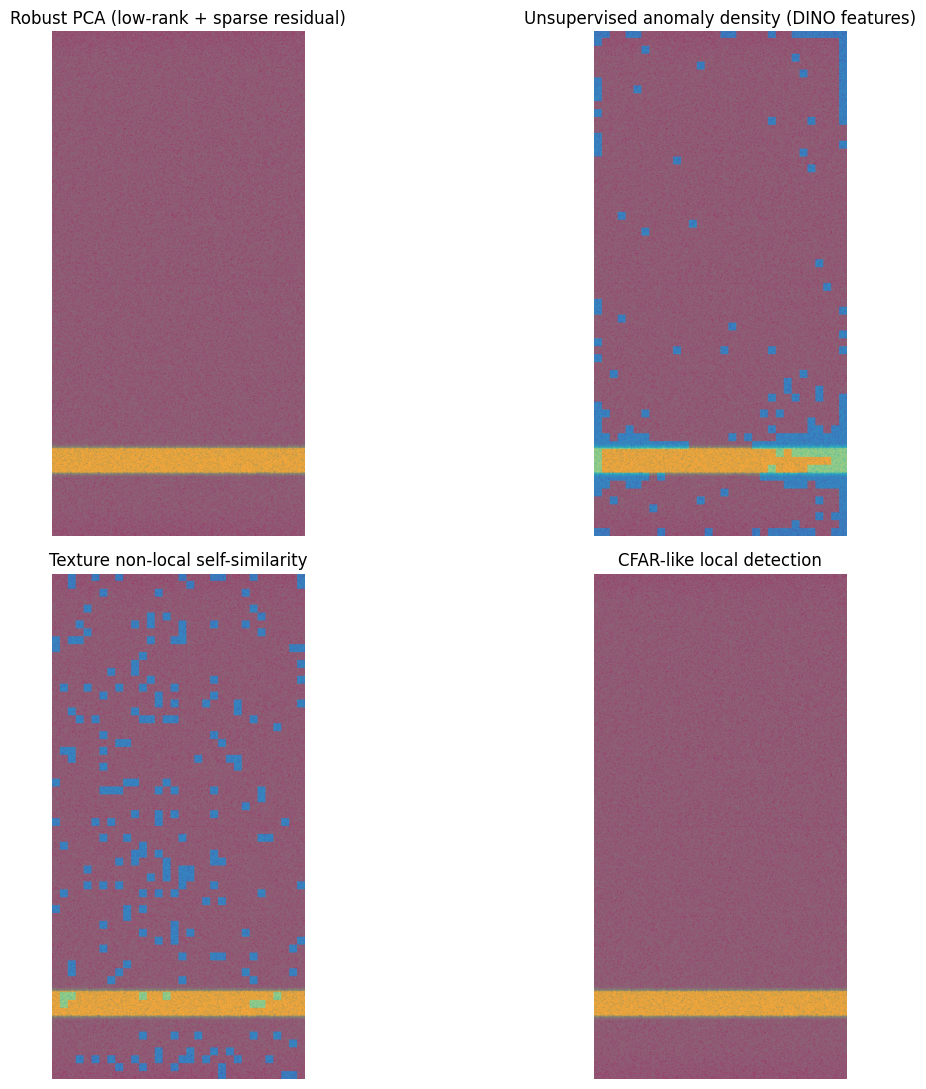

Literature-aligned mask metrics:


,smoothness,edge_disagreement,num_components,foreground_fraction
method,,,,
robust_pca,1.000000,0.000000,1,0.000000
cfar_like,1.000000,0.000000,1,0.000000
anomaly_density,0.905306,0.094694,62,0.100098
texture_nonlocal,0.826465,0.173535,156,0.100098


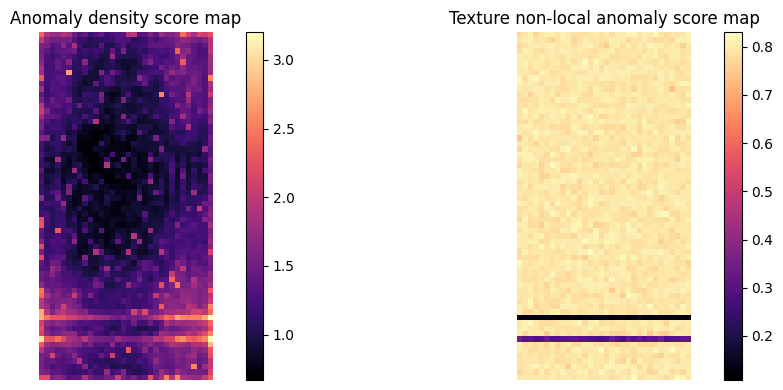

In [20]:
# Visual + metric comparison for the literature-aligned methods
fig, ax = plt.subplots(2, 2, figsize=(14, 11))

ax[0, 0].imshow(literature_overlays['robust_pca'])
ax[0, 0].set_title('Robust PCA (low-rank + sparse residual)')
ax[0, 0].axis('off')

ax[0, 1].imshow(literature_overlays['anomaly_density'])
ax[0, 1].set_title('Unsupervised anomaly density (DINO features)')
ax[0, 1].axis('off')

ax[1, 0].imshow(literature_overlays['texture_nonlocal'])
ax[1, 0].set_title('Texture non-local self-similarity')
ax[1, 0].axis('off')

ax[1, 1].imshow(literature_overlays['cfar_like'])
ax[1, 1].set_title('CFAR-like local detection')
ax[1, 1].axis('off')

plt.tight_layout()
plt.show()

lit_rows = []
for name, mask in literature_masks.items():
    m = _smoothness_metrics(mask)
    m['method'] = name
    lit_rows.append(m)

literature_df = pd.DataFrame(lit_rows).set_index('method').sort_values('foreground_fraction')
print('Literature-aligned mask metrics:')
display(literature_df)

# Optional: inspect anomaly and texture score maps.
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
im0 = ax[0].imshow(score_anom, cmap='magma')
ax[0].set_title('Anomaly density score map')
ax[0].axis('off')
plt.colorbar(im0, ax=ax[0], fraction=0.046)

im1 = ax[1].imshow(score_tex, cmap='magma')
ax[1].set_title('Texture non-local anomaly score map')
ax[1].axis('off')
plt.colorbar(im1, ax=ax[1], fraction=0.046)

plt.tight_layout()
plt.show()